# Online Learning Course Consumption Analysis

This notebook analyzes learner behavior using the Kaggle *Online Learning Course Consumption Dataset*.

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [3]:

df = pd.read_csv(r"E:\analytics\data\online_learning_course_consumption_dataset.csv")
df.head()


,User_ID,Experience_Level,Course_Type,Platform,Hours_Spent_Per_Week,Course_Duration_Weeks,Completion_Status,Completion_Percentage,Dropout_Reason,Satisfaction_Score
0,U0001,Fresher,Tech,Skillshare,16,8,Completed,67,No Dropout,2
1,U0002,Fresher,Non-Tech,edX,17,22,Dropped,38,Time Constraint,3
2,U0003,Fresher,Non-Tech,Coursera,19,21,In Progress,43,No Dropout,1
3,U0004,Student,Non-Tech,Udemy,14,2,Dropped,14,Time Constraint,1
4,U0005,Student,Non-Tech,Skillshare,8,10,Dropped,8,Too Difficult,4


## Dataset Overview

In [5]:
df.shape

(500, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   User_ID                500 non-null    object
 1   Experience_Level       500 non-null    object
 2   Course_Type            500 non-null    object
 3   Platform               500 non-null    object
 4   Hours_Spent_Per_Week   500 non-null    int64 
 5   Course_Duration_Weeks  500 non-null    int64 
 6   Completion_Status      500 non-null    object
 7   Completion_Percentage  500 non-null    int64 
 8   Dropout_Reason         500 non-null    object
 9   Satisfaction_Score     500 non-null    int64 
dtypes: int64(4), object(6)
memory usage: 39.2+ KB


In [7]:
df.describe()

,Hours_Spent_Per_Week,Course_Duration_Weeks,Completion_Percentage,Satisfaction_Score
count,500.000000,500.000000,500.000000,500.000000
mean,10.560000,13.256000,50.480000,3.022000
std,5.520085,6.506853,26.973259,1.434445
min,1.000000,2.000000,5.000000,1.000000
25%,6.000000,8.000000,30.750000,2.000000
50%,11.000000,13.500000,46.000000,3.000000
75%,15.000000,19.000000,73.000000,4.000000
max,20.000000,24.000000,100.000000,5.000000


## Data Cleaning

In [9]:
df.isnull().sum()

User_ID                  0
Experience_Level         0
Course_Type              0
Platform                 0
Hours_Spent_Per_Week     0
Course_Duration_Weeks    0
Completion_Status        0
Completion_Percentage    0
Dropout_Reason           0
Satisfaction_Score       0
dtype: int64

In [10]:
df.drop_duplicates(inplace=True)

In [ ]:
df.fillna(method='fill', inplace=True)

## Top 10 Most Enrolled Courses

In [15]:
df.columns


Index(['User_ID', 'Experience_Level', 'Course_Type', 'Platform',
       'Hours_Spent_Per_Week', 'Course_Duration_Weeks', 'Completion_Status',
       'Completion_Percentage', 'Dropout_Reason', 'Satisfaction_Score'],
      dtype='object')

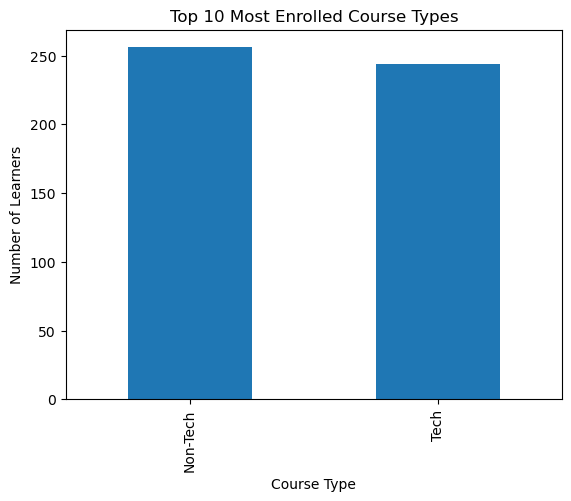

In [19]:
df['Course_Type'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Most Enrolled Course Types")
plt.xlabel("Course Type")
plt.ylabel("Number of Learners")
plt.show()

## Course Platform Distribution

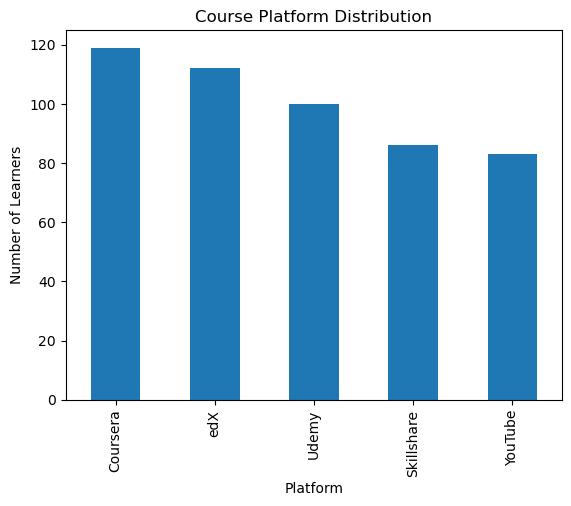

In [20]:
df['Platform'].value_counts().plot(kind='bar')
plt.title("Course Platform Distribution")
plt.xlabel("Platform")
plt.ylabel("Number of Learners")
plt.show()

## Course Completion Rate

In [21]:

completion_rate = df['Completion_Status'].value_counts(normalize=True) * 100
completion_rate

Completion_Status
Dropped        34.6
In Progress    34.2
Completed      31.2
Name: proportion, dtype: float64

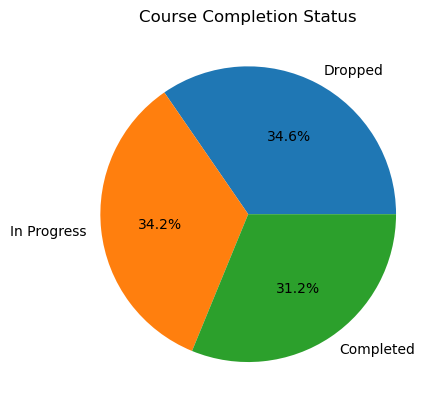

In [22]:
completion_rate.plot(kind='pie', autopct='%1.1f%%')
plt.title("Course Completion Status")
plt.ylabel("")
plt.show()

## Time Spent vs Completion

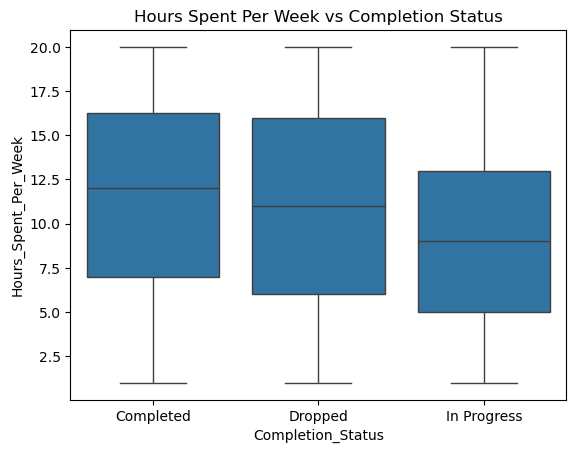

In [23]:
sns.boxplot(data=df, x='Completion_Status', y='Hours_Spent_Per_Week')
plt.title("Hours Spent Per Week vs Completion Status")
plt.show()

# Completion Percentage by Course Type

In [24]:
df.groupby('Course_Type')['Completion_Percentage'] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10)

Course_Type
Non-Tech    51.175781
Tech        49.750000
Name: Completion_Percentage, dtype: float64

# Satisfaction vs Completion

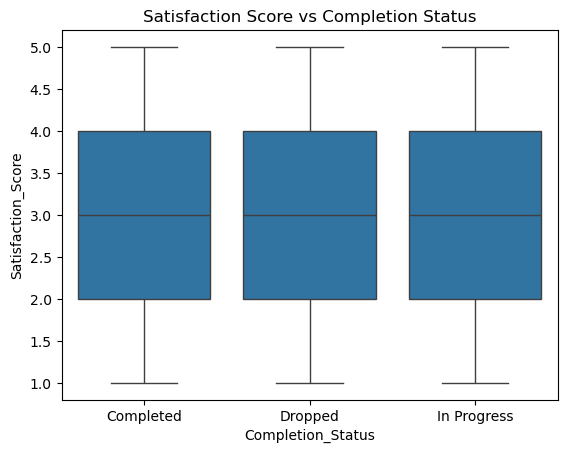

In [25]:
sns.boxplot(data=df, x='Completion_Status', y='Satisfaction_Score')
plt.title("Satisfaction Score vs Completion Status")
plt.show()

## Key Insights
- Learners spending more hours per week are more likely to complete courses
- Certain course types have higher completion percentages
- Platform choice impacts engagement
- Satisfaction score is higher among course completers